**Import the libraries**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Loading the Dataset

In [3]:
df = sns.load_dataset("mpg") #Miles per gallon dataset

In [4]:
df.head()# gives the first 5 rows of the dataset

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
df.info() # gives the information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
df.drop(["name"], axis=1, inplace=True) # dropping the name column as it is not useful for our analysis

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


Summary of Data

In [9]:
df.describe() # gives the statistical summary of the dataset

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Data Preprocessing

In [10]:
df.isnull().sum() # checking for missing values in the dataset

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [11]:
df[df.isnull().any(axis=1)] # gives the rows with missing values

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
32,25.0,4,98.0,NaN,2046,19.0,71,usa
126,21.0,6,200.0,NaN,2875,17.0,74,usa
330,40.9,4,85.0,NaN,1835,17.3,80,europe
336,23.6,4,140.0,NaN,2905,14.3,80,usa
354,34.5,4,100.0,NaN,2320,15.8,81,europe
374,23.0,4,151.0,NaN,3035,20.5,82,usa


In [12]:
df.dropna(inplace=True) # drops the rows with missing values

In [15]:
df.isnull().sum().any() # checking for missing values in the dataset

np.False_

In [16]:
df.shape # gives the number of rows and columns in the dataset

(392, 8)

Univariate Analysis

In [17]:
df.cylinders.unique() # gives the unique values in the cylinders column

array([8, 4, 6, 3, 5])

In [18]:
df.cylinders.value_counts() # gives the count of each unique value in the cylinders column

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

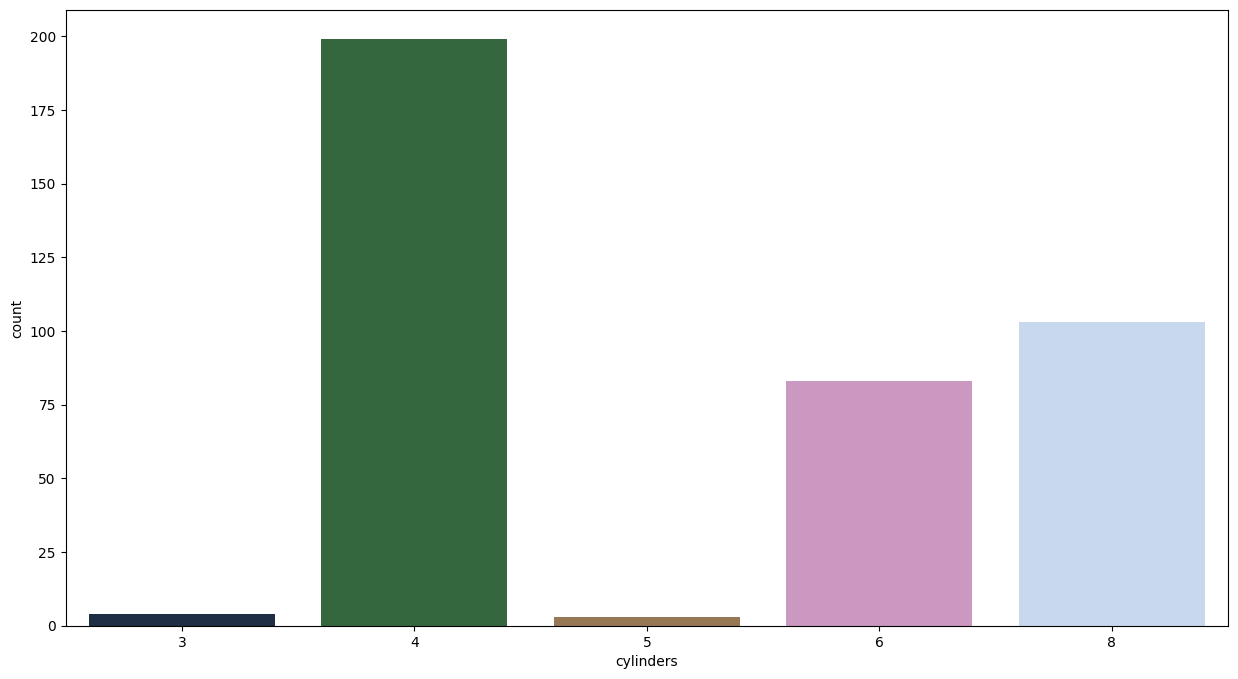

In [21]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="cylinders", palette="cubehelix")
plt.show()

In [22]:
df["model_year"]= (1900 + df.model_year) # converting the model_year column to a more readable format

In [24]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,1970,usa
1,15.0,8,350.0,165.0,3693,11.5,1970,usa
2,18.0,8,318.0,150.0,3436,11.0,1970,usa
3,16.0,8,304.0,150.0,3433,12.0,1970,usa
4,17.0,8,302.0,140.0,3449,10.5,1970,usa


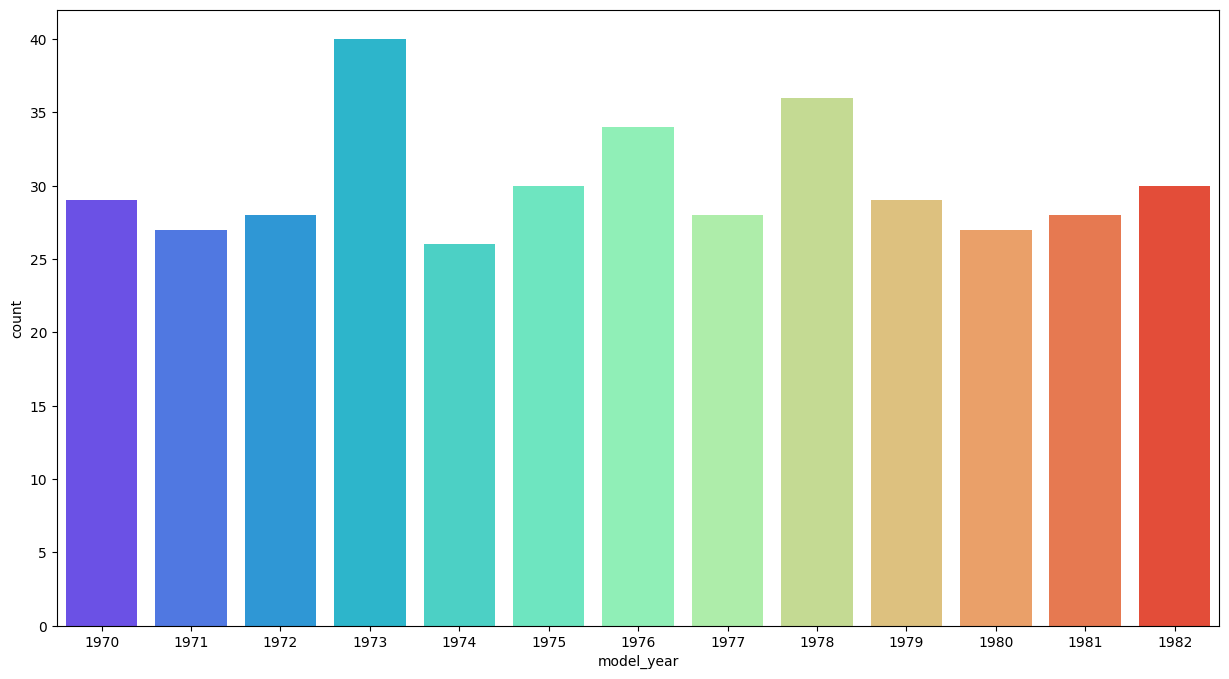

In [26]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="model_year", palette="rainbow")
plt.show()

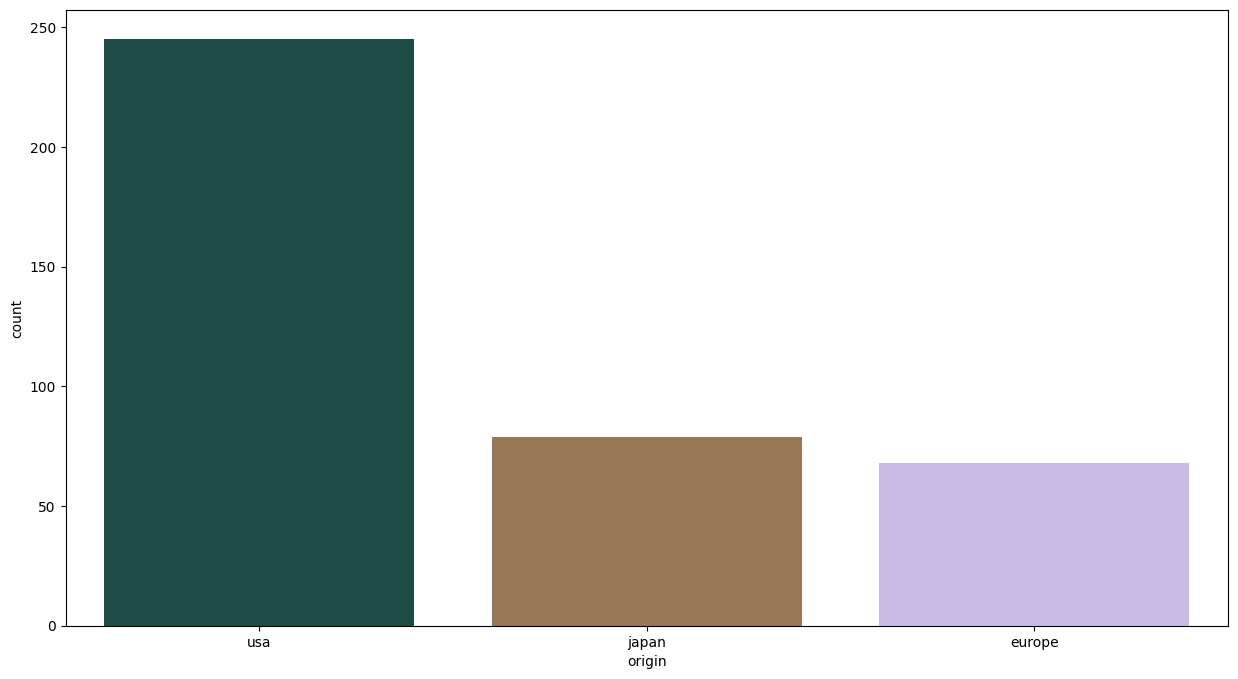

In [29]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="origin", palette="cubehelix")
plt.show()

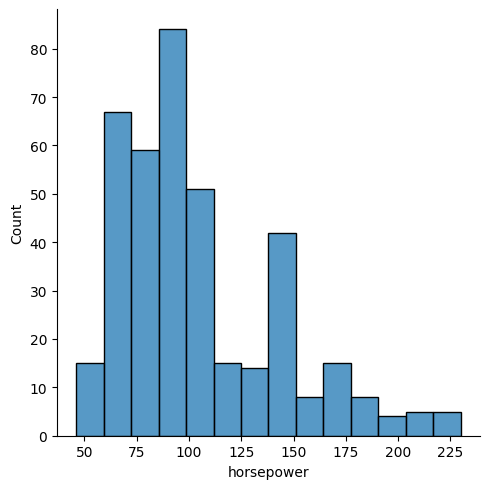

In [ ]:
sns.displot(df["horsepower"])# gives the distribution of the horsepower column
plt.show()

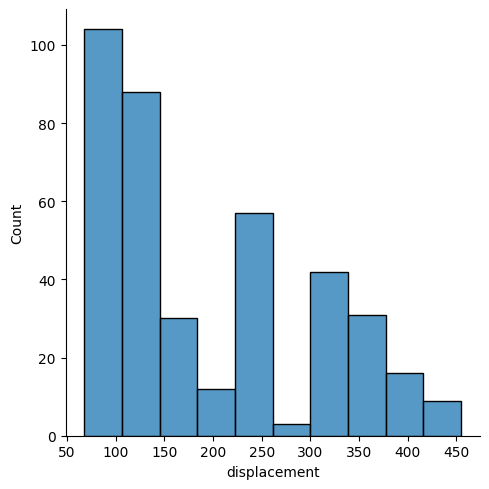

In [33]:
sns.displot(df["displacement"])# gives the distribution of the displacement column
plt.show()

Bivariate Analysis

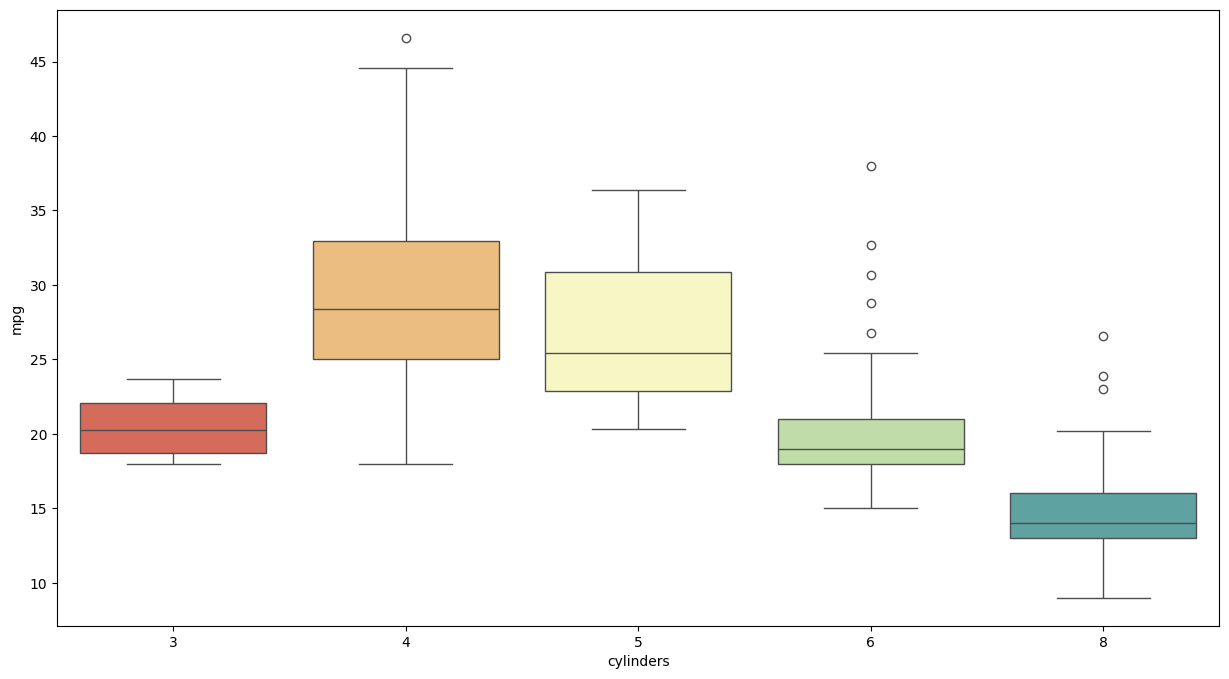

In [35]:
#target variable is miles per gallon(mpg) and the rest are the features. We will use the features to predict the target variable.
plt.figure(figsize=(15,8))
sns.boxplot(x= "cylinders", y="mpg", data=df, palette="Spectral") # gives the boxplot of the miles per gallon for each cylinder category
plt.show()

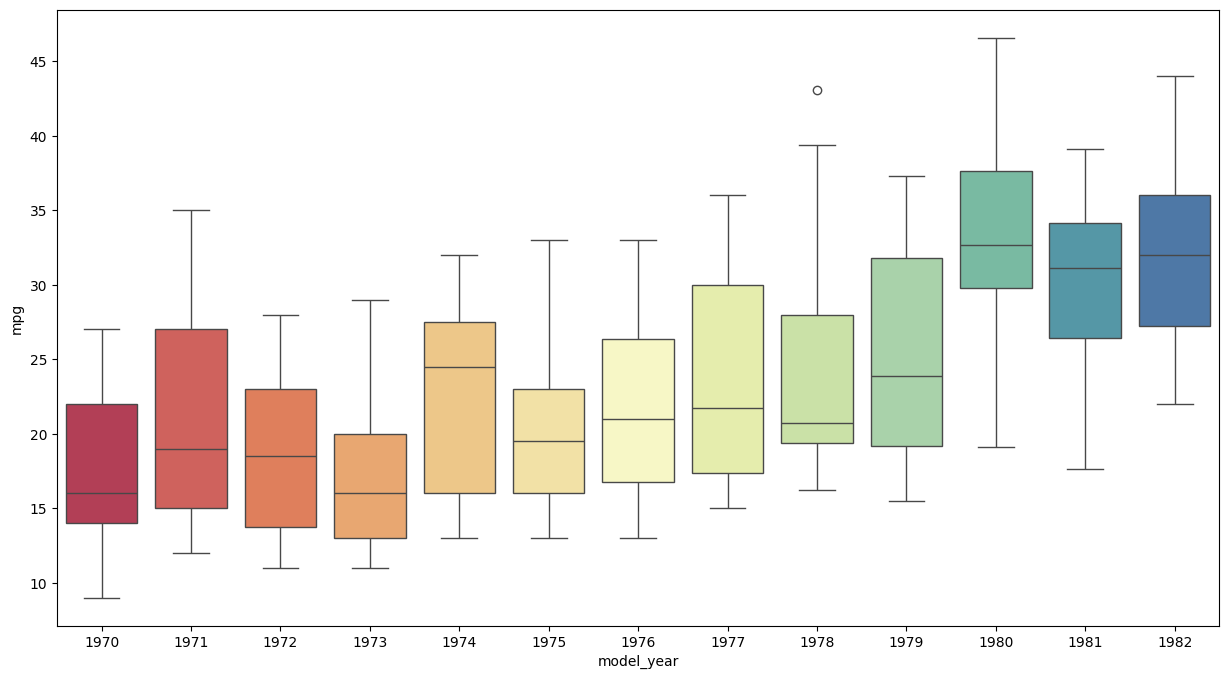

In [36]:
plt.figure(figsize=(15,8))
sns.boxplot(x= "model_year", y="mpg", data=df, palette="Spectral")
plt.show()

Multivariate Analysis

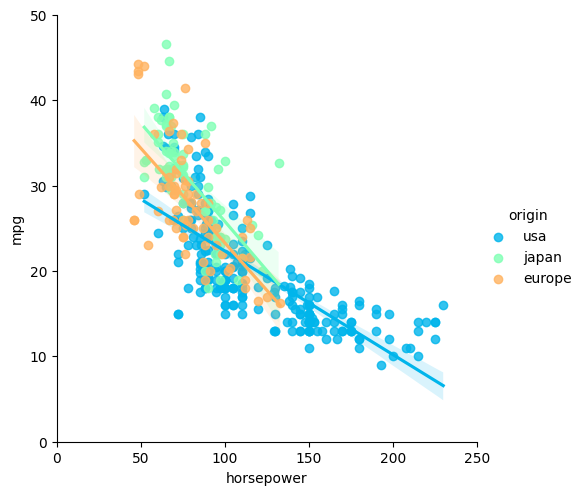

In [41]:
graph=sns.lmplot(x="horsepower", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of horsepower vs miles per gallon with different colors for different origins
graph.set(xlim=(0, 250), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

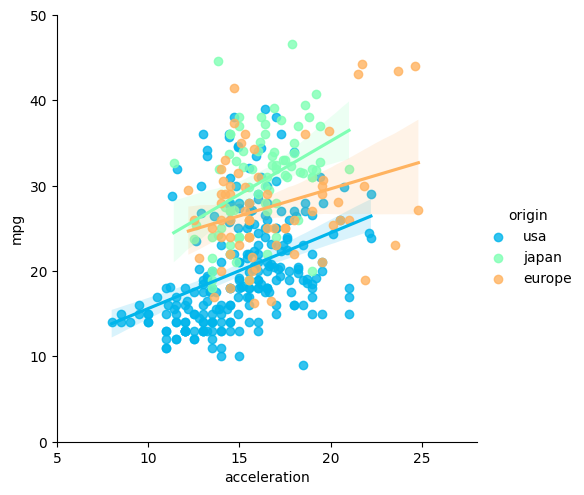

In [45]:
graph=sns.lmplot(x="acceleration", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of acceleration vs miles per gallon with different colors for different origins
graph.set(xlim=(5, 28), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

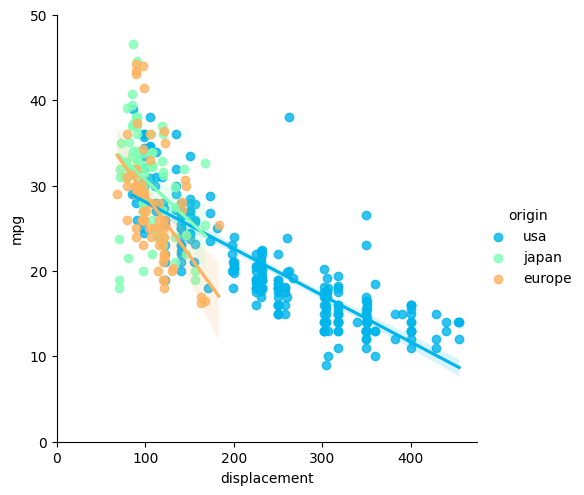

In [46]:
graph=sns.lmplot(x="displacement", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of displacement vs miles per gallon with different colors for different origins
graph.set(xlim=(0,475), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

Heatmap of the Correlation Matrix

In [52]:
df.drop(["origin"], axis=1, inplace=True) # dropping the name column as it is not useful for our analysis

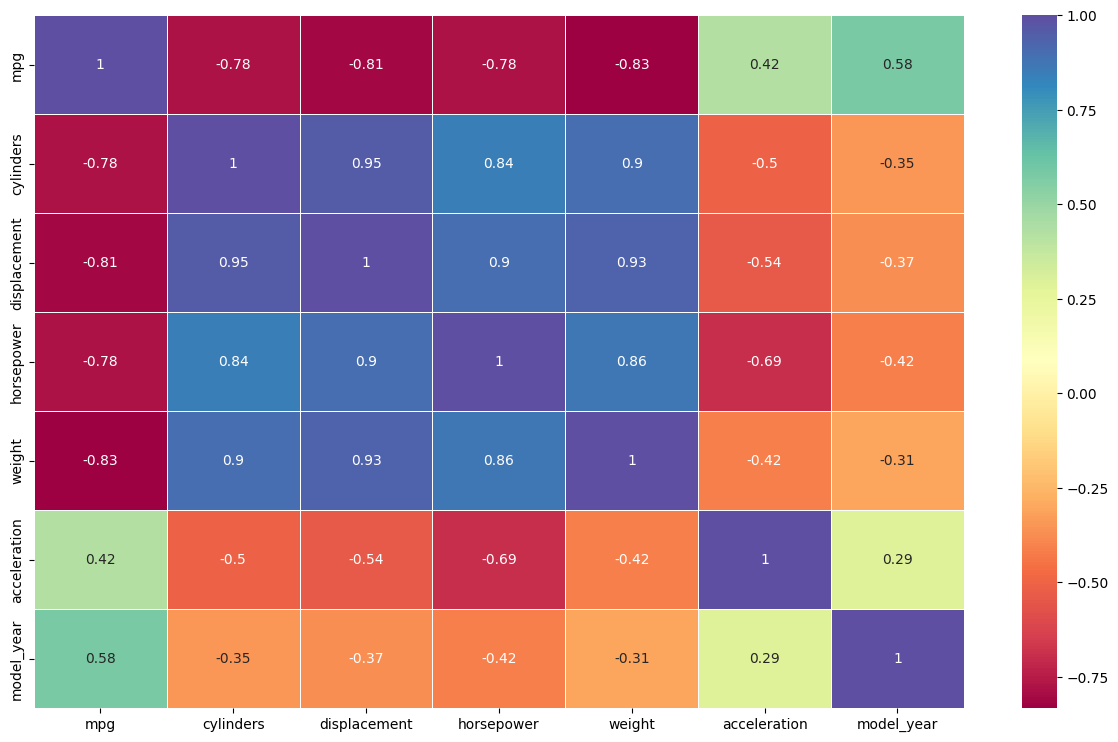

In [53]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(),annot= True,linewidth=0.5, cmap="Spectral") # gives the heatmap of the correlation between the features and the target variable
plt.show()

In [55]:
df.drop(["acceleration", "displacement"], axis=1, inplace=True) # dropping the acceleration and displacement columns as they are not useful for our analysis])

In [56]:
from datetime import datetime
today = datetime.today()

In [57]:
today

datetime.datetime(2026, 4, 9, 11, 4, 7, 675777)

In [58]:
this_year=today.year
df["age"]= this_year - df.model_year # creating a new column age which is the difference between the current year and the model year of the car

In [59]:
df.drop(["model_year"], axis=1, inplace=True) # dropping the model_year column as it is not useful for our analysis